In [1]:
from arcengine import GameAction, FrameDataRaw
from arc_agi import OperationMode
import arc_agi
from google.genai import types
from google import genai
from log import write_log, start_server, _render_grid
from typing import Any, Union
import argparse
import base64 as b64_mod
import hashlib
import json
import logging
import mimetypes
import subprocess
import numpy as np
from matplotlib import pyplot as plt
from dotenv import load_dotenv
from IPython.display import display
from PIL import Image
load_dotenv()


PALETTE = np.array([
    [0xFF, 0xFF, 0xFF], [0xCC, 0xCC, 0xCC], [0x99, 0x99, 0x99],
    [0x66, 0x66, 0x66], [0x33, 0x33, 0x33], [0x00, 0x00, 0x00],
    [0xE5, 0x3A, 0xA3], [0xFF, 0x7B, 0xCC], [0xF9, 0x3C, 0x31],
    [0x1E, 0x93, 0xFF], [0x88, 0xD8, 0xF1], [0xFF, 0xDC, 0x00],
    [0xFF, 0x85, 0x1B], [0x92, 0x12, 0x31], [0x4F, 0xCC, 0x30],
    [0xA3, 0x56, 0xD6],
], dtype=np.uint8)


def render_frame(frame: np.ndarray) -> Image.Image:
    rgb = PALETTE[np.clip(np.asarray(frame, dtype=np.uint8), 0, 15)]
    return Image.fromarray(rgb).resize((512, 512), Image.NEAREST)


logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s %(message)s", datefmt="%H:%M:%S")

In [ ]:
ARCADE = arc_agi.Arcade(operation_mode=OperationMode("normal"))
SCORECARD_ID = ARCADE.open_scorecard(tags=["jackagent"])

# arcengine/enums.py: GameAction
VALID_ACTIONS = {"ACTION1", "ACTION2", "ACTION3", "ACTION4",
                 "ACTION5", "ACTION6", "ACTION7", "RESET"}


class MyArcSession:
    def __init__(self, game_id: str):
        self.env = ARCADE.make(game_id=game_id, scorecard_id=SCORECARD_ID)
        self.last_obs: FrameDataRaw | None = None
        self.obs: FrameDataRaw | None = self.env.reset()

    def reset(self):
        self.prev_obs = None
        self.obs = self.env.reset()

    def do_action(self, action: GameAction):
        if action == GameAction.RESET:
            self.reset()
            return
        self.last_obs = self.obs
        data = {}  # TODO: support click
        self.obs = self.env.step(action, data=data)

    def do_action_from_name(self, action_name: str):
        ga = GameAction.from_name(action_name)
        self.do_action(action=ga)


2026-04-12 20:33:35 | INFO | Successfully fetched 25 environment(s) from API


20:33:35 Successfully fetched 25 environment(s) from API


2026-04-12 20:33:35 | INFO | Created new scorecard: 38775aab-93c3-46a0-86e9-0b09cd8ee6ec


20:33:35 Created new scorecard: 38775aab-93c3-46a0-86e9-0b09cd8ee6ec


In [19]:
arc_session = MyArcSession(["ls20", "ft09"][0])

2026-04-12 20:39:17 | INFO | Successfully fetched metadata for game ls20


20:39:17 Successfully fetched metadata for game ls20


2026-04-12 20:39:17 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


20:39:17 Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


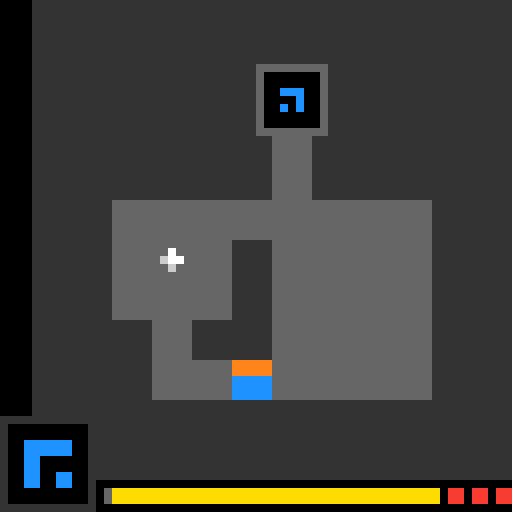

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 3,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


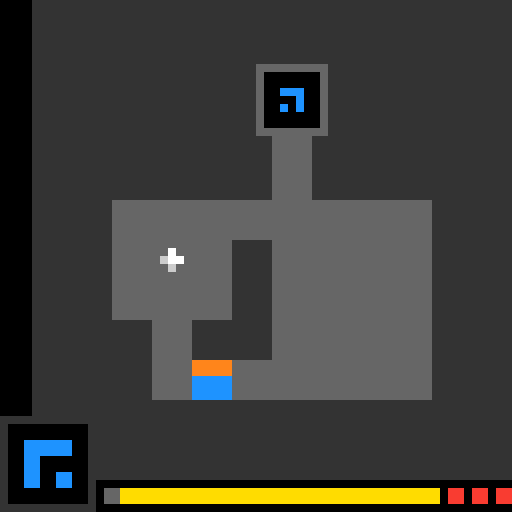

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 3,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


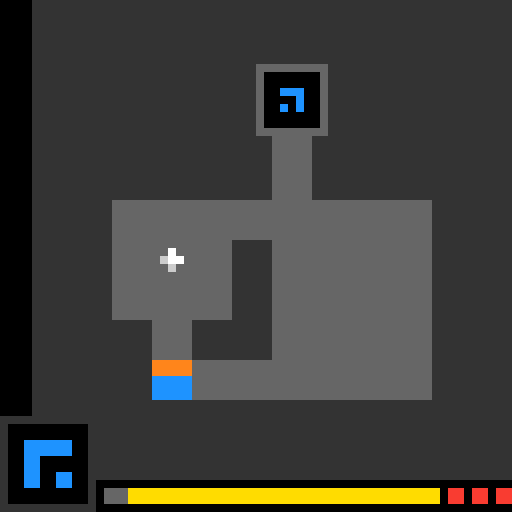

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 3,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


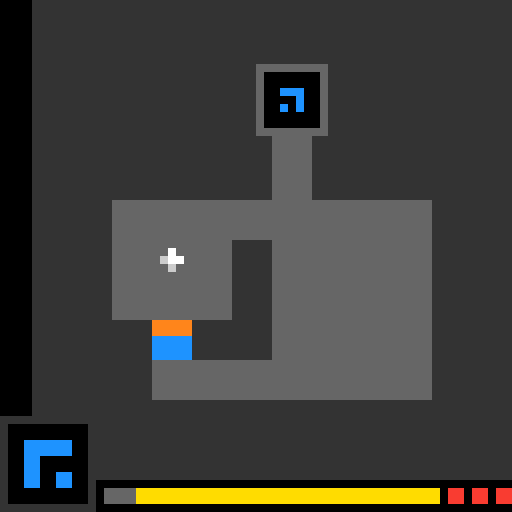

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


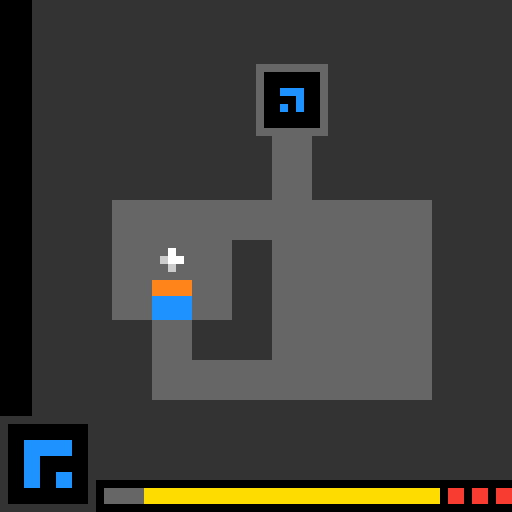

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


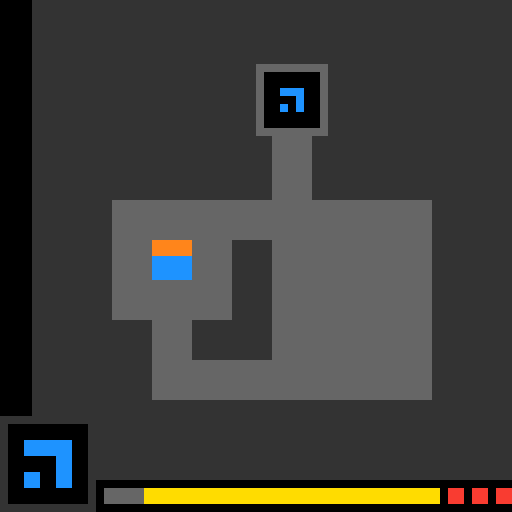

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


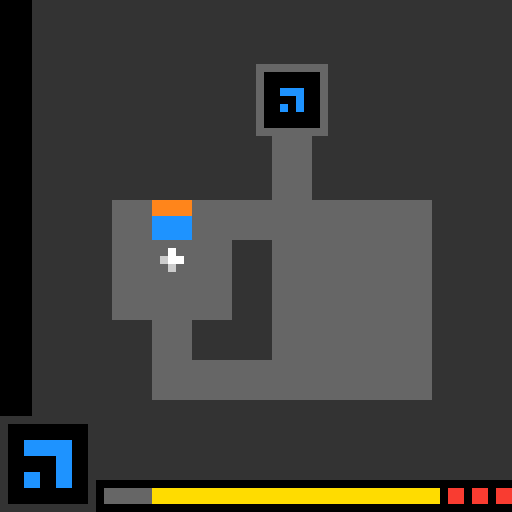

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


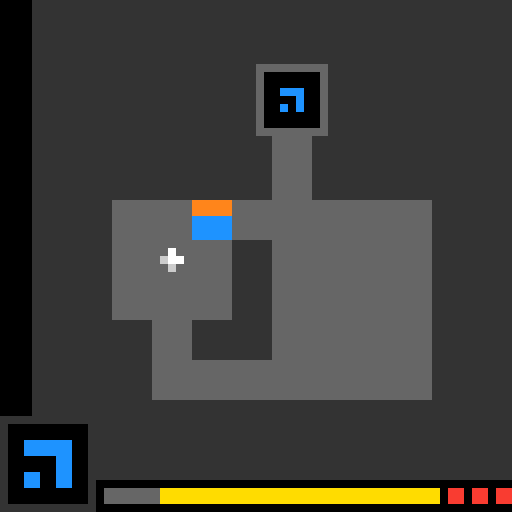

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 4,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


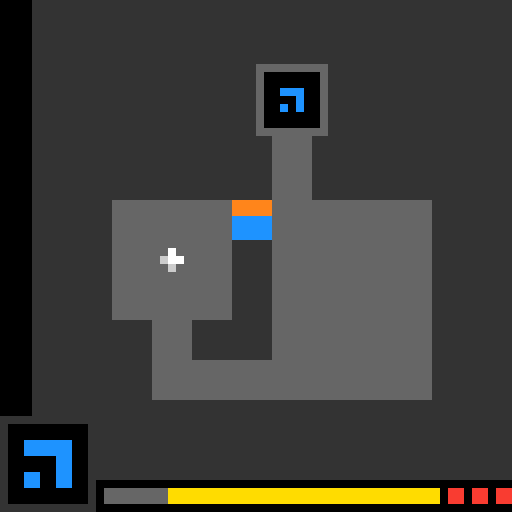

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 4,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


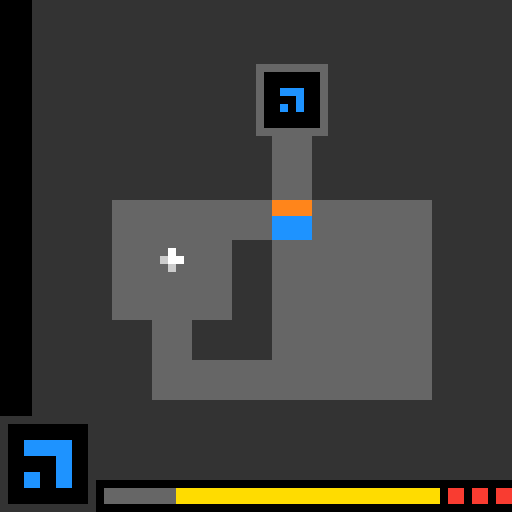

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 4,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


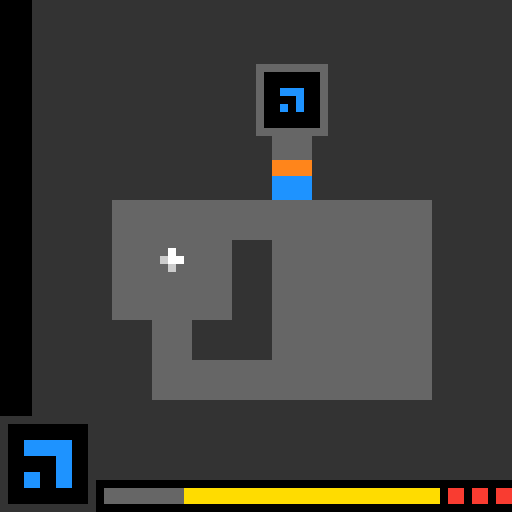

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


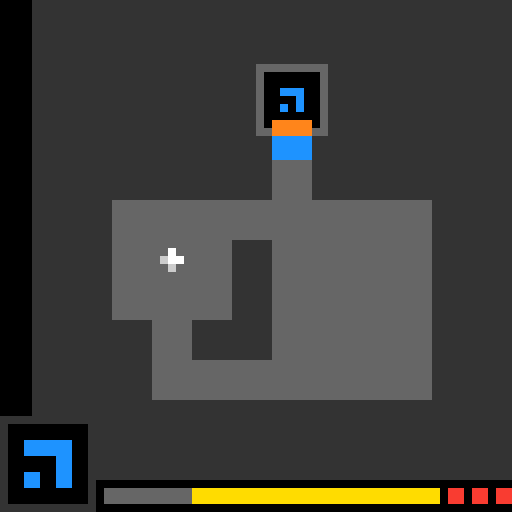

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


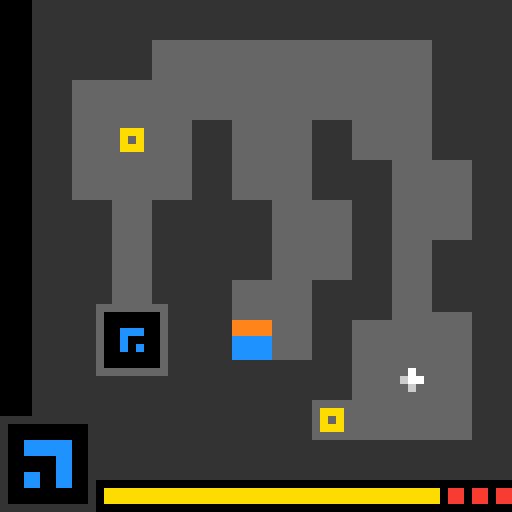

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 1,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


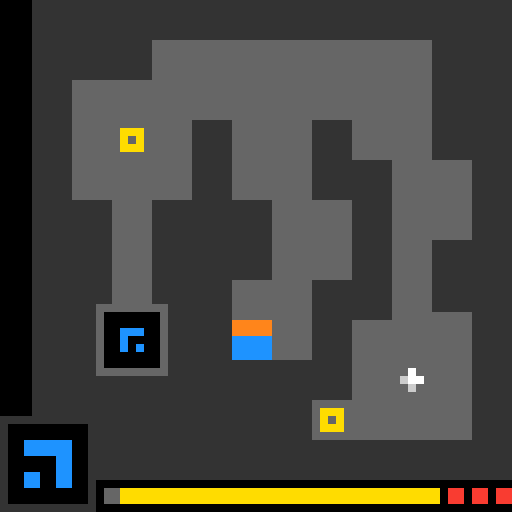

{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 1,
  "win_levels": 7,
  "action_input": {
    "id": 3,
    "data": {},
    "reasoning": null
  },
  "guid": "5b44462d-ad5e-47a0-ba21-0bcbe7f586b8",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


In [16]:
win_lvl_1_actions = 3 * [GameAction.ACTION3] + 4 * [GameAction.ACTION1] + \
    3 * [GameAction.ACTION4] + 3 * [GameAction.ACTION1] + [GameAction.ACTION3]

for a in win_lvl_1_actions:
    arc_session.do_action(a)
    display(render_frame(arc_session.obs.frame[-1]))
    print(arc_session.obs)

GameState.NOT_FINISHED


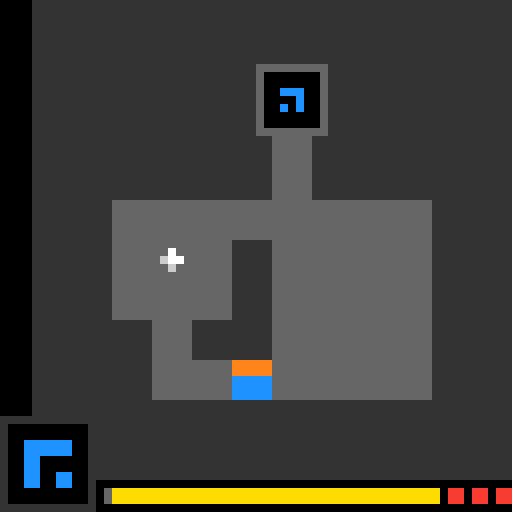

GameState.NOT_FINISHED


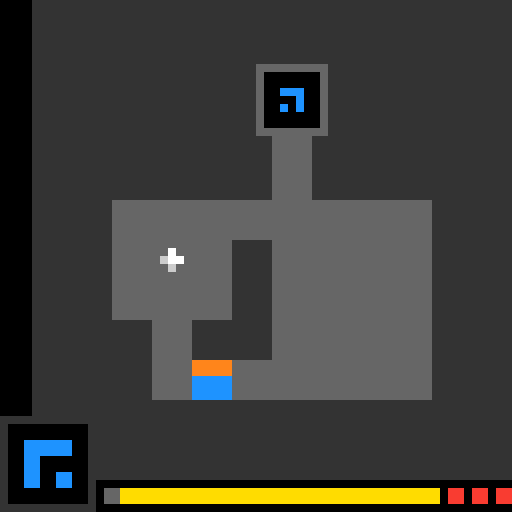

GameState.NOT_FINISHED


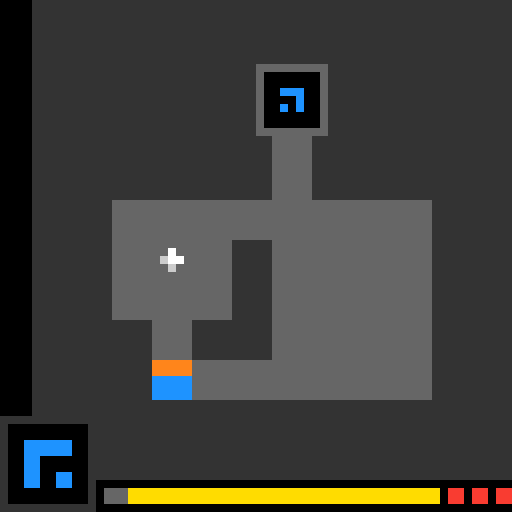

GameState.NOT_FINISHED


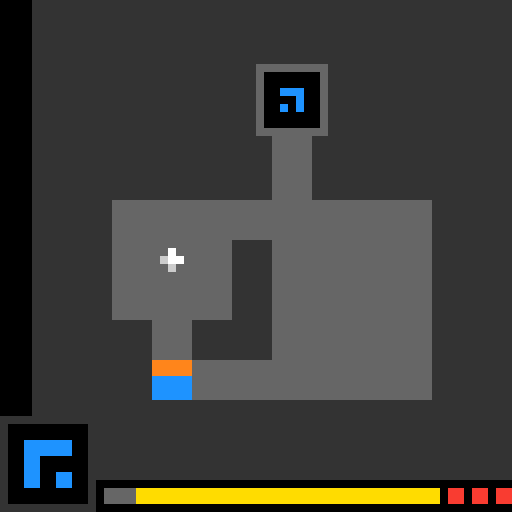

GameState.NOT_FINISHED


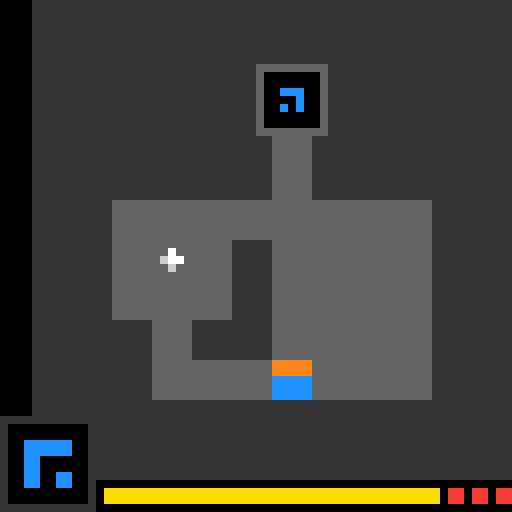

GameState.NOT_FINISHED


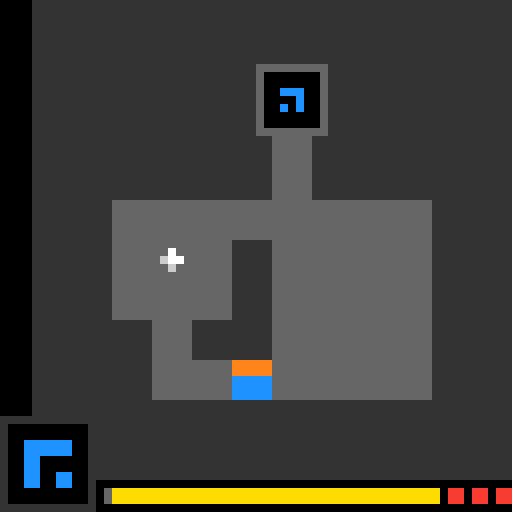

GameState.NOT_FINISHED


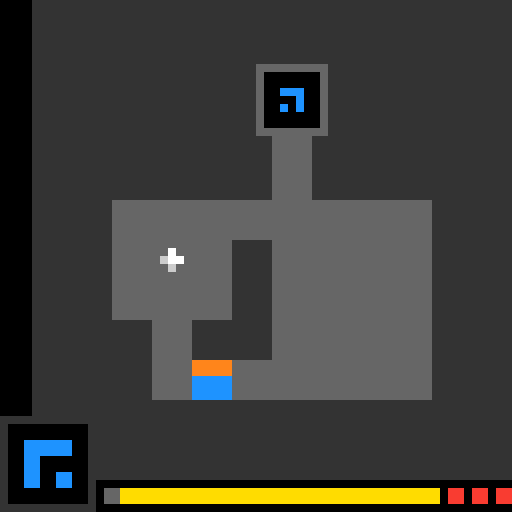

GameState.NOT_FINISHED


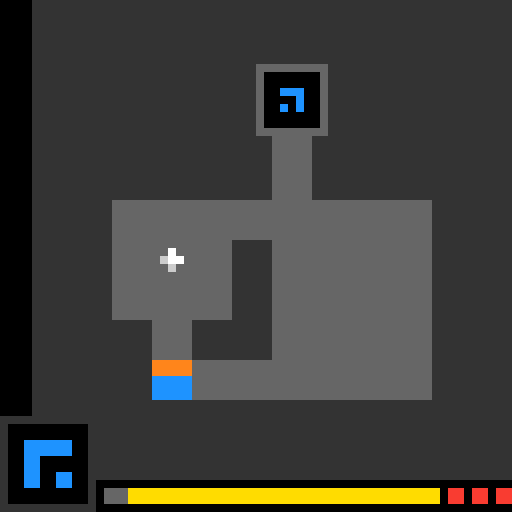

In [20]:
loose_lvl_1_actions = [GameAction.ACTION3] * 4 + [GameAction.RESET] + [GameAction.ACTION3] * 3

for a in loose_lvl_1_actions:
    arc_session.do_action(a)
    print(arc_session.obs.state)
    display(render_frame(arc_session.obs.frame[-1]))

In [6]:

SYSTEM_PROMPT = """\
You are playing an interactive puzzle game on a 64x64 grid.

Each cell is an integer 0-15 representing a color. You don't know the game rules. \
You must figure them out by experimenting: take actions, observe what changes, \
build a theory, test it.

After each action you receive:
- state: NOT_FINISHED, WIN, or GAME_OVER
- score: levels completed so far (a score increase means a level was solved)
- win_levels: total levels needed to win
- available_actions: which actions are legal right now (only use these)
- A board image showing the current grid state
- A diff of what changed since the last action
- A memory of actions already tried from this board state

The full 64x64 grid is also written to /home/agent/state.json after every action.

Actions:
- ACTION1: up
- ACTION2: down
- ACTION3: left
- ACTION4: right
- ACTION5: interact / confirm (game-specific)
- ACTION6: click a cell at (x, y) where x,y in [0,63]
- ACTION7: undo
- RESET: restart the current level

Color palette (0-15):
0=white 1=off-white 2=light-gray 3=gray 4=off-black 5=black \
6=magenta 7=light-magenta 8=red 9=blue 10=light-blue 11=yellow \
12=orange 13=maroon 14=green 15=purple

You have a Linux sandbox (working dir /home/agent) with Python 3.12, numpy, \
matplotlib, pillow, and sudo. You can run any command, write scripts, install packages.

A helpers.py file is pre-loaded with:
- load_grid() → numpy array of the current 64x64 grid
- load_obs() → full observation dict
- diff_grids(old, new) → list of (row, col, old_val, new_val)
- color_counts(grid) → {color: count}
- find_color(grid, val) → [(row, col), ...]
Use: python3 -c "from helpers import *; grid = load_grid(); print(color_counts(grid))"

Goal: reach WIN state in as few actions as possible.\
"""

RUN_COMMAND = {
    "name": "run_command",
    "description": (
        "Run a shell command in the sandbox. Working directory is /home/agent. "
        "Python 3.12, numpy, matplotlib, pillow are available. "
        "Commands run as bash -c so pipes and chaining work."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "command": {
                "type": "string",
                "description": "Shell command to execute as a clean string.",
            },
        },
        "required": ["command"],
    },
}

VIEW_FILE = {
    "name": "view_file",
    "description": (
        "View an image or PDF from the sandbox. The file is added to your visual "
        "context so you can see and analyze it. Supports images (png, jpg, gif, webp) "
        'and PDFs. Do NOT use this for text files — read those with run_command("cat path") instead.'
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "path": {
                "type": "string",
                "description": "Absolute path to an image or PDF in the sandbox.",
            },
        },
        "required": ["path"],
    },
}

TAKE_ACTION = {
    "name": "take_action",
    "description": (
        "Submit a game action. Returns state, score, available_actions, a board image, "
        "a diff of changes, and memory of previously tried actions. "
        "For ACTION6 (click), x and y are required (0-63)."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "action": {
                "type": "string",
                "enum": ["ACTION1", "ACTION2", "ACTION3", "ACTION4",
                         "ACTION5", "ACTION6", "ACTION7", "RESET"],
                "description": "The action to take.",
            },
            "x": {
                "type": "integer",
                "description": "X coordinate for ACTION6 (0-63). Ignored for other actions.",
            },
            "y": {
                "type": "integer",
                "description": "Y coordinate for ACTION6 (0-63). Ignored for other actions.",
            },
        },
        "required": ["action"],
    },
}

RENDER_BOARD = {
    "name": "render_board",
    "description": "Render the current game board as a PNG image. No arguments needed.",
    "parameters": {
        "type": "object",
        "properties": {},
    },
}

TOOLS = [RUN_COMMAND, VIEW_FILE, TAKE_ACTION, RENDER_BOARD]


MODELS = ["gemini-3-flash-preview", "gemini-3.1-pro-preview"]

CONFIG = types.GenerateContentConfig(
    system_instruction=SYSTEM_PROMPT,
    tools=[types.Tool(function_declarations=TOOLS)],
    automatic_function_calling=types.AutomaticFunctionCallingConfig(
        disable=True),
    temperature=1.0,
    media_resolution=types.MediaResolution.MEDIA_RESOLUTION_MEDIUM,
    candidate_count=1,
    stop_sequences=[],
    thinking_config=types.ThinkingConfig(thinking_level="high"),
)


def generate_start_prompt(obs: FrameDataRaw) -> str:
    return (
        f"New game started. Initial state:\n{json.dumps(obs, indent=2)}\n\n"
        f"The full grid is in /home/agent/state.json. "
        f"Start by calling render_board to see the board, then take actions to explore."
    )


class JackAgent():
    def __init__(self):
        self.client = genai.Client()
        self.model = MODELS[1]
        self.contents: list[types.Content] = []
        self.clear()

    def clear(self, start_prompt):
        self.contents = [types.Content(
            role="user", parts=[types.Part(text=start_prompt)])]

    def generate_response(self) -> types.GenerateContentResponse:
        res = self.client.models.generate_content(
            model=self.model, contents=self.contents, config=CONFIG,
        )
        model_content = res.candidates[0].content
        calls = [p for p in model_content.parts if p.function_call]

        if not calls:
            print("did not make a tool call")
            self.contents.append(model_content)

        result_parts = []

        for p in calls:
            print(f"made {len(calls)} tool calls")
            fc: types.FunctionCall = p.function_call
            output: dict = execute_tool(fc.name, fc.args)

            if fc.name == "take_action":
                action_count += 1
            else:
                preview = output["result"] if isinstance(
                    output["result"], str) else str(output["result"])
                
            fr_kwargs = {
                "name": fc.name,
                "response": {"result": output["result"]},
                "id": fc.id,
            }
            if "_bytes" in output:
                fr_kwargs["parts"] = [types.FunctionResponsePart(
                    inline_data=types.FunctionResponseBlob(
                        mime_type=output["_mime"],
                        display_name="board.png",
                        data=output["_bytes"],
                    )
                )]

            result_parts.append(
                types.Part(
                    function_response=types.FunctionResponse(**fr_kwargs))
            )

        self.contents.append(types.Content(role="user", parts=result_parts))